In [1]:
import numpy as np
import time
import sys
import os

import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import multiprocess
import seaborn as sb
from tqdm import tqdm

from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.utils import timer
from inception.quantlib_python import date_to_date
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote

import mocaxextendpy.mocax_extend as me

In [2]:
def autocallable_note_pricer(x: list, additonal_data = None):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, stock B price, stock C price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    import numpy as np
    import pandas as pd
    from inception.instruments.constant_parameters import NOTES_PARAMETERS
    from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
    
    start_date = '2024-02-14'
    # Input parameters:
    spot_price = np.array(x[:3])
    eval_date = pd.Timestamp(start_date) + pd.Timedelta(days=x[3])
    
    corr_matrix = np.array(
        [[1.        , 0.96432854, 0.80799003],
        [0.96432854, 1.        , 0.8267037 ],
        [0.80799003, 0.8267037 , 1.        ]]
    )
    issued_price = [382.82, 494.08, 142.86]
    index_vol = [0.16, 0.16, 0.16]
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(eval_date,
                                       ['A', 'B', 'C'],
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)

    
    return notes.value

In [3]:
## -- Deserialization
mocax_extend = me.MocaxExtend.deserialize("./chebyshev_database/autocallable_tensor_extension_0.pickle")

In [51]:
func = lambda x: np.random.uniform(x * 0.5, x * 1.3)

# Function domain for stock A, B and C price, Time to Maturity
issued_price = [382.82, 494.08, 142.86]
random_x = [[func(d) for d in issued_price] + [np.random.choice(np.arange(0, 91))] for _ in range(3)]

t1 = time.time()
value_m = [mocax_extend.cheb_tensor_evals(np.array([x]))[0] for x in random_x]

t2 = time.time()
# value_p = [autocallable_note_pricer(x) for x in random_x]
t3 = time.time()

In [55]:
t1 = time.time()
value_m = mocax_extend.cheb_tensor_evals(np.array(random_x)) 

t2 = time.time()

In [56]:
a = (t2-t1) / 100

In [57]:
b = (t3-t2) / 100

In [58]:
a

0.00010102033615112304

In [8]:
18557595856

1.3536876940727234

In [20]:
b / a

237.2840490938175

For a 3 underlying indexes Autocallable Notes, the call time of the origianl pricer(Monte Carlo Simulation) is 2 second, the call time of machine learning approximator is 0.007 second, it is almost 300 times faster. what is more, the call time of machine learning approximator is constant not matter how complicate the original pricer is. if we use the machine learning approximator to replace more complicate instrument pricer the gain even larger.

Maximum error: 1.29224
Mean error: 0.20057


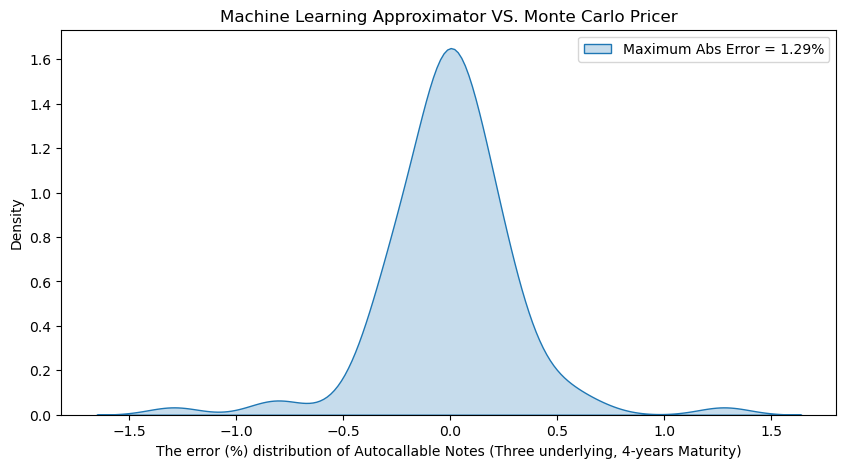

In [40]:
plt.figure(figsize=(10, 5))
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('Machine Learning Approximator VS. Monte Carlo Pricer')
plt.xlabel('The error (%) distribution of Autocallable Notes (Three underlying, 4-years Maturity)')
plt.legend(labels=[f'Maximum Abs Error = {max(abs(error_2)):.2f}%'])
# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")